# Podcast Emotion and Content Analysis

This project explores the linguistic, emotional, and topical characteristics of podcast episodes using Natural Language Processing (NLP) methods.  
By combining pre-trained language models and structured metadata, we aim to uncover the emotional tone, thematic categories, and audience alignment of each podcast episode.

Our pipeline operates at two complementary levels:
- **Turn-level analysis:** Emotion detection and safety tagging for individual speaker turns.
- **Episode-level analysis:** Aggregation of features to classify episodes into genres, estimate audience interests, and identify potentially unsafe content.


### Motivation

Podcasts are a rich and fast-growing medium, with content ranging from personal storytelling to political commentary.  
However, the scale and diversity of podcast data make manual analysis impractical.  

Automatic understanding of podcast episodes can support:
- **Listeners**, by improving recommendation and discovery systems.
- **Producers**, by providing insights into emotional tone and audience engagement.
- **Platforms**, by enabling automated content moderation and brand safety filtering.

Despite advances in text-based NLP, podcasts present unique challenges: conversational structure, speaker variability, and diverse topics.  
This project seeks to address these challenges by building an interpretable and scalable NLP pipeline tailored for podcast data.


### Project Goals

The primary objectives of this project are:

1. **Turn-level emotion detection** — Identify emotions (e.g., joy, anger, sadness) in each speaker turn using a pre-trained emotion recognition model.
2. **Episode-level categorization** — Classify each episode into broad categories such as *Technology*, *Comedy*, or *Politics*.
3. **Brand safety detection** — Flag episodes that contain unsafe or sensitive content, including hate speech, violence, or adult themes.
4. **Audience alignment prediction** — Estimate the likely audience or interest group best aligned with each episode based on its emotional and linguistic profile.

Collectively, these tasks aim to produce an interpretable summary of each episode — showing how speakers’ emotions, topics, and tone interact across the conversation.


### Expected Outcomes

By the end of this project, we aim to:
- Deliver a fully documented pipeline capable of processing large-scale podcast transcript data.
- Demonstrate emotion and safety predictions on speaker turns using transformer-based models.
- Aggregate turn-level features to classify and describe entire episodes.
- Provide interpretable summaries for each episode showing emotion distribution, category prediction, and safety assessment.

This proof of concept validates that pre-trained NLP models can be combined and scaled to perform fine-grained, multi-level podcast analysis.


## 1. Data Loading and Overview

To start, we'll load the sample datasets, `episodeLevelDataSample` and `speakerTurnDataSample`. The full datasets are over 20 GB, so we're using these smaller versions for the demonstration in this milestone.

In [1]:
import gzip
import json
import pandas as pd

episode_level = []
with gzip.open("data/episodeLevelDataSample.jsonl.gz", "rt", encoding="utf-8") as f:
    for line in f:
        episode_level.append(json.loads(line))

episode_df = pd.DataFrame(episode_level)

In [2]:
speakerTurn = []
with gzip.open("data/speakerTurnDataSample.jsonl.gz", "rt", encoding="utf-8") as f:
    for line in f:
        speakerTurn.append(json.loads(line))

speaker_df = pd.DataFrame(speakerTurn)

### Columns and Examples

#### Episode Level

The `episodeLevelDataSample` dataset provides metadata for each podcast episode in the sample, including information like the episode title, description, podcast title, and categories. The mp3url in this dataset is particularly important as it acts as a unique identifier for each episode, allowing us to link it with the corresponding speaker turn data later on. We'll use this data to understand the context of the speaker turns and potentially for tasks like episode classification and analysis based on episode-level features.

In [3]:
print("episodeLevelDataSample columns: ", episode_df.keys())

print("\n episodeLevelDataSample examples: ")
episode_df.sample(5) # Display 5 random samples from the dataset

episodeLevelDataSample columns:  Index(['transcript', 'rssUrl', 'epTitle', 'epDescription', 'mp3url',
       'podTitle', 'lastUpdate', 'itunesAuthor', 'itunesOwnerName', 'explicit',
       'imageUrl', 'language', 'createdOn', 'host', 'podDescription',
       'category1', 'category2', 'category3', 'category4', 'category5',
       'category6', 'category7', 'category8', 'category9', 'category10',
       'oldestEpisodeDate', 'episodeDateLocalized', 'durationSeconds',
       'hostPredictedNames', 'numUniqueHosts', 'guestPredictedNames',
       'numUniqueGuests', 'neitherPredictedNames', 'numUniqueNeithers',
       'mainEpSpeakers', 'numMainSpeakers', 'hostSpeakerLabels',
       'guestSpeakerLabels', 'overlapPropTurnCount', 'avgTurnDuration',
       'overlapPropDuration', 'totalSpLabels'],
      dtype='object')

 episodeLevelDataSample examples: 


,transcript,rssUrl,epTitle,epDescription,mp3url,podTitle,lastUpdate,itunesAuthor,itunesOwnerName,explicit,...,neitherPredictedNames,numUniqueNeithers,mainEpSpeakers,numMainSpeakers,hostSpeakerLabels,guestSpeakerLabels,overlapPropTurnCount,avgTurnDuration,overlapPropDuration,totalSpLabels
1246,Good morning friends brothers and sisters. It...,http://feeds.feedburner.com/CovenantBaptistChu...,The Woman at the Well,None,http://dts.podtrac.com/redirect.mp3/http://s3....,Covenant Baptist Church Sermon Audio,1697579008,Covenant Baptist Church,Covenant Baptist Church,0,...,NO_NEITHER_IDENTIFIED,0.0,[SPEAKER_00],1.0,SPEAKER_DATA_UNAVAILABLE,SPEAKER_DATA_UNAVAILABLE,0.4,437.524,0.00048,2.0
98,(upbeat music) - Welcome to today's episode o...,https://anchor.fm/s/a95405c/podcast/rss,100 Ways to Get It,<p>Everyone should have a side hustle – a part...,https://anchor.fm/s/a95405c/podcast/play/15728...,What's in the Words,1623926031,"AJ Joiner, Steve Canal","AJ Joiner, Steve Canal",1,...,[Chris Gilball],1.0,"[SPEAKER_00, SPEAKER_01]",2.0,{'Steve Kanau': 'SPEAKER_00'},SPEAKER_DATA_UNAVAILABLE,0.409091,14.097273,0.02458,2.0
2852,[Music] You are about to enter the world of t...,https://anchor.fm/s/1208abf8/podcast/rss,#20 - Do You Believe In Miracles?,WHAT. AN. EPISODE. THIS. WEEK. The episodes ke...,https://anchor.fm/s/1208abf8/podcast/play/1362...,Improversation,1652246188,Improversation Podcast,Improversation Podcast,1,...,NO_NEITHER_IDENTIFIED,0.0,"[SPEAKER_02, SPEAKER_04]",2.0,{'Mike Cassian': 'SPEAKER_04'},SPEAKER_DATA_UNAVAILABLE,0.487723,4.739509,0.103626,6.0
7445,[Music] Ambition is critical. [Music] I'm bac...,https://feeds.buzzsprout.com/126179.rss,Episode 113: Chicken Run,<p>The world has gone mad but the lunatics run...,https://www.buzzsprout.com/126179/4047278-epis...,Ambition is Critical,1697750652,ambition-is-critical,ambition-is-critical,0,...,NO_NEITHER_IDENTIFIED,0.0,"[SPEAKER_01, SPEAKER_03]",2.0,SPEAKER_DATA_UNAVAILABLE,SPEAKER_DATA_UNAVAILABLE,0.467018,9.394459,0.082512,4.0
5657,Welcome to Woodycast episode number five. Bef...,https://feeds.buzzsprout.com/251762.rss,WOODYCAST INTERVIEW # 5 WITH MAIA GARNER,"<p>In his first remote interview, Woody talks ...",https://www.buzzsprout.com/251762/3755669-wood...,WOODYCAST,1608380025,WOODY,WOODY,0,...,[Michael King],1.0,SPEAKER_DATA_UNAVAILABLE,SPEAKER_DATA_UNAVAILABLE,SPEAKER_DATA_UNAVAILABLE,SPEAKER_DATA_UNAVAILABLE,SPEAKER_DATA_UNAVAILABLE,SPEAKER_DATA_UNAVAILABLE,SPEAKER_DATA_UNAVAILABLE,SPEAKER_DATA_UNAVAILABLE


#### Speaker Turn Level

The `speakerTurnDataSample` dataset contains information about individual speaker turns within each podcast episode. This includes the most important one which is the actual text spoken (`turnText`), the identified speaker, the start and end times of the turn, and the mp3url to link it back to the episode metadata in the episodeLevelDataSample.

In [4]:
print("speakerTurnDataSample columns: ", speaker_df.keys())

print("\n speakerTurnDataSample examples: ")
speaker_df.sample(5) # Display 5 random samples from the dataset

speakerTurnDataSample columns:  Index(['mfcc1_sma3Mean', 'mfcc2_sma3Mean', 'mfcc3_sma3Mean', 'mfcc4_sma3Mean',
       'F0semitoneFrom27.5Hz_sma3nzMean', 'F1frequency_sma3nzMean', 'turnText',
       'speaker', 'startTime', 'endTime', 'duration', 'mp3url', 'turnCount',
       'inferredSpeakerRole', 'inferredSpeakerName'],
      dtype='object')

 speakerTurnDataSample examples: 


,mfcc1_sma3Mean,mfcc2_sma3Mean,mfcc3_sma3Mean,mfcc4_sma3Mean,F0semitoneFrom27.5Hz_sma3nzMean,F1frequency_sma3nzMean,turnText,speaker,startTime,endTime,duration,mp3url,turnCount,inferredSpeakerRole,inferredSpeakerName
121413,12.001105,-10.014420,15.346855,-4.085402,4.445988,735.989894,.,"[SPEAKER_02, SPEAKER_03]",623.07,623.24,0.17,https://www.buzzsprout.com/776315/3995819-knig...,242,NO_INFERRED_ROLE,NO_INFERRED_SPEAKER
196795,25.914298,3.417711,23.590561,1.328182,20.091549,691.121920,'re probably right now can i tell you what i t...,[SPEAKER_00],4191.05,4193.06,2.01,https://traffic.libsyn.com/secure/itgetsweird/...,519,NO_INFERRED_ROLE,NO_INFERRED_SPEAKER
30984,23.398031,-3.052274,20.295945,6.412578,17.297410,715.168994,Yeah. Yeah. Who cares? We,[SPEAKER_06],559.54,562.65,3.11,https://mcdn.podbean.com/mf/web/7pibib/Rated_R...,88,NO_INFERRED_ROLE,NO_INFERRED_SPEAKER
77710,26.246465,6.436799,5.770432,2.577989,5.536414,727.473360,to me with a little cup of tea and he'd go ou...,[SPEAKER_02],270.20,296.21,26.01,https://www.buzzsprout.com/11042/4190801-regat...,24,NO_INFERRED_ROLE,NO_INFERRED_SPEAKER
109187,9.485720,11.075450,13.165492,0.960168,3.388262,548.833602,off,"[SPEAKER_01, SPEAKER_02]",1140.95,1141.37,0.42,https://traffic.omny.fm/d/clips/820f09cf-2ace-...,93,NO_INFERRED_ROLE,NO_INFERRED_SPEAKER


Given the large number of columns in these datasets, we want to select a subset of columns from each that are relevant to our analysis and discard the rest.

## 2. Data Preprocessing

In this section, we perform a series of preprocessing steps to prepare the dataset for downstream analysis and modeling.

The primary objective is to retain only the most relevant information from the raw `speakerTurnData` and `episodeLevelData` sources while ensuring that textual fields — particularly `turnText` — are clean, standardized, and ready for the tasks.

This involves:

* Selecting key columns that capture speaker and episode metadata.
* Cleaning and normalizing text data to remove noise (e.g., music markers, punctuation, excess whitespace).
* Filtering out irrelevant or empty content.
* Aggregating speaker turns and merging with episode-level information for a unified dataset.

### 2.1 Select Relevant Columns (Speaker-Turn Data)
We extract a subset of columns from the original dataset to create a compact version containing the most informative features for each speaker turn.

| Column                  | Description                                                |
| :---------------------- | :--------------------------------------------------------- |
| **turnText**            | Transcribed text of the speaker’s turn                     |
| **speaker**             | Identifier for the speaker                                 |
| **mp3url**              | Link to the episode (useful for grouping turns by episode) |
| **turnCount**           | Sequential position of the turn within an episode          |
| **inferredSpeakerRole** | Predicted speaker role (e.g., host, guest)                 |
| **startTime**           | Start time of a turn                                       |
| **endTime**             | End time of a turn                                         |


In [5]:
cols = ['turnText', 'speaker', 'mp3url', 'turnCount', 'inferredSpeakerRole',  'startTime', 'endTime']
speaker_df1 = pd.DataFrame(speakerTurn)[cols].copy()

### 2.2 Text Normalization

We standardize the text to lowercase and normalize whitespace.
This step ensures consistent tokenization and reduces vocabulary redundancy (e.g., “The” and “the” are treated the same).

In [6]:
speaker_df1['turnText'] = (
    speaker_df1['turnText']
    .str.lower()
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

### 2.3 Noise Removal

The transcripts contain several types of non-linguistic artifacts such as musical cues, blank-audio markers, ellipses, and transcription symbols.

These tokens provide no semantic value and can bias subsequent NLP analysis.

To obtain cleaner text representations, we remove all non-speech elements and normalize leftover formatting.

In [7]:
import re

# --- 1. Define stronger unwanted patterns ---
# Matches variations like:
# [music], (music playing), [background music fades], music:, blank_audio etc.
unwanted_patterns = [
    r'\[.*?music.*?\]',       # [music], [background music], [music playing]
    r'\(.*?music.*?\)',       # (music), (music playing), (background music)
    r'\[.*?blank_audio.*?\]', # [blank_audio] or variations
    r'\(.*?blank_audio.*?\)', # (blank_audio)
    r'\bmusic\b',             # standalone 'music'
    r'\bblank_audio\b'        # standalone 'blank_audio'
]

# --- 2. Apply removal ---
for pattern in unwanted_patterns:
    speaker_df1['turnText'] = speaker_df1['turnText'].str.replace(pattern, '', regex=True)

# --- 3. Clean malformed or stray brackets ---
def clean_brackets(text):
    """Removes stray [ or ] while preserving valid bracketed expressions."""
    return re.sub(r'(\[[^\[\]]+\])|[\[\]]', lambda m: m.group(1) or '', text)

speaker_df1['turnText'] = speaker_df1['turnText'].apply(clean_brackets)

# --- 4. Remove conversation markers or ellipses ---
speaker_df1['turnText'] = (
    speaker_df1['turnText']
    .str.replace('>>', '', regex=False)
    .str.replace(r'\.\.\.', '', regex=True)  # remove ...
)

# --- 5. Remove near-empty or symbol-only entries ---
speaker_df1 = speaker_df1[speaker_df1['turnText'].str.len() > 1]
speaker_df1 = speaker_df1[~speaker_df1['turnText'].str.match(r'^\W*$')]

# --- 6. Final whitespace normalization ---
speaker_df1['turnText'] = speaker_df1['turnText'].str.replace(r'\s+', ' ', regex=True).str.strip()


### 2.4 Example Output

In [8]:
target_url = "https://traffic.megaphone.fm/APO4719798278.mp3"
speaker_df_example = speaker_df1[speaker_df1['mp3url'] == target_url]
speaker_df_example[['speaker','turnText']]

,speaker,turnText
869,[SPEAKER_01],let's go. make no excuses now. i'm talking her...
870,[SPEAKER_02],hi
871,[SPEAKER_00],". welcome to get you fit radio with your host,..."
872,"[SPEAKER_00, SPEAKER_01]",slowly she
873,[SPEAKER_00],started introducing carbs again. the weight st...


----------- 

# TO BE REMOVED

In [9]:
target_url = "https://traffic.megaphone.fm/APO4719798278.mp3"
# Show example
speaker_df_example = speaker_df1[speaker_df1['mp3url'] == target_url]
for index, row in speaker_df_example.iterrows():
    print(row['turnText'][:150])

let's go. make no excuses now. i'm talking here and now. i'm talking here and now. let's go. you're timing one minute now. i'm talking here and now. i
hi
. welcome to get you fit radio with your host, irene cook. the radio show that helps you lead a healthy lifestyle. well, at this point, anybody that h
slowly she
started introducing carbs again. the weight stayed off for a while. until it started creeping out again. before she knew it, she'd gain back all over 


As you can see, some values  in turnText only contains "Music] [Music] ... [Music] [Music]", which means that this section of the podcast is currently playing a song. We want to filter  these sections out. We start by lowering everything to lowercase letters. This both makes the filtering  step easier, but  also helps training the model later on  as it helps treat words like "The" and "the" as the same token, reducing vocabulary size.

Additionally, some sections of the turnText string contains multiple whitespace in a row, so we also fix that here, by replacing those with a single space.

In [10]:
speaker_df1 = speaker_df1.copy()

# Convert text to lowercase
speaker_df1['turnText'] = speaker_df1['turnText'].str.lower()

# Replace multiple spaces with a single space
speaker_df1['turnText'] = speaker_df1['turnText'].str.replace(r'\s+', ' ', regex=True)

# Show example
speaker_df_example = speaker_df1[speaker_df1['mp3url'] == target_url]
for index, row in speaker_df_example.iterrows():
    print(row['turnText'][:150])

let's go. make no excuses now. i'm talking here and now. i'm talking here and now. let's go. you're timing one minute now. i'm talking here and now. i
hi
. welcome to get you fit radio with your host, irene cook. the radio show that helps you lead a healthy lifestyle. well, at this point, anybody that h
slowly she
started introducing carbs again. the weight stayed off for a while. until it started creeping out again. before she knew it, she'd gain back all over 


Now we can filter  out the music-sections.

In [11]:
# Remove music indicators from the turnText
# Remove specific music indicators and blank audio patterns
unwanted_patterns_strict = [
    r'\[music\]', r'\[music playing\]', r'\[blank_audio\]',
    r'music\]', r'\[music', r'music playing\]', r'\[music playing',
    r'blank_audio\]', r'\[blank_audio', r'\(music\)'
]
for pattern in unwanted_patterns_strict:
    speaker_df1['turnText'] = speaker_df1['turnText'].str.replace(pattern, '', regex=True)

# Remove multiple whitespaces
speaker_df1['turnText'] = speaker_df1['turnText'].str.replace(r'\s+', ' ', regex=True)

# Remove leading/trailing whitespace
speaker_df1['turnText'] = speaker_df1['turnText'].str.strip()

# Show example
speaker_df_example = speaker_df1[speaker_df1['mp3url'] == target_url]
for index, row in speaker_df_example.iterrows():
    print(row['turnText'][:150])

let's go. make no excuses now. i'm talking here and now. i'm talking here and now. let's go. you're timing one minute now. i'm talking here and now. i
hi
. welcome to get you fit radio with your host, irene cook. the radio show that helps you lead a healthy lifestyle. well, at this point, anybody that h
slowly she
started introducing carbs again. the weight stayed off for a while. until it started creeping out again. before she knew it, she'd gain back all over 


Now we have almost removed all instances of music-section. Unfortunately, sometimes the music string is seperated like:

[  
music  
]  

which means some of our filtering steps are not being processed properly. We fix this by first removing all rows that only has the words "music", "music playing" and "blank_audio" present.


In [12]:
import re

# Remove rows that still contains the singles words after cleaning
speaker_df1 = speaker_df1[speaker_df1['turnText'] != 'music']
speaker_df1 = speaker_df1[speaker_df1['turnText'] != 'music playing']
speaker_df1 = speaker_df1[speaker_df1['turnText'] != 'blank_audio']

# Show example
speaker_df_example = speaker_df1[speaker_df1['mp3url'] == target_url]
for index, row in speaker_df_example.iterrows():
    print(row['turnText'][:150])

let's go. make no excuses now. i'm talking here and now. i'm talking here and now. let's go. you're timing one minute now. i'm talking here and now. i
hi
. welcome to get you fit radio with your host, irene cook. the radio show that helps you lead a healthy lifestyle. well, at this point, anybody that h
slowly she
started introducing carbs again. the weight stayed off for a while. until it started creeping out again. before she knew it, she'd gain back all over 


 Now the single instances "music" has been discarded. However, we  notice that the single characters "[" and "]" are still present. Of course we want to remove these characters. But we have to be careful. We want to ensure that we keep instances of "[laughs]",  "[applauds]" and other types of  reactions that might occur, as removing brackets in such cases could confuse the model into believing that these are  words  being said.  So we define a regex function that only removes brackets if they are empty/invalid.

 Furthermore, we ensure that other singular characters such as ".", "_", ":" ect. also gets filtered out by deleting lines that only contains single character.

In [13]:
# Define the cleaning regex function
def clean_brackets(text):
    # Keep valid [content], remove stray [ or ]
    return re.sub(r'(\[[^\[\]]+\])|[\[\]]', lambda m: m.group(1) or '', text)

speaker_df1['turnText'] = speaker_df1['turnText'].apply(clean_brackets)

# Remove rows that only contain single characters (or less)
speaker_df1 = speaker_df1[speaker_df1['turnText'].str.len() > 1]

# Show example
speaker_df_example = speaker_df1[speaker_df1['mp3url'] == target_url]
for index, row in speaker_df_example.iterrows():
    print(row['turnText'][:150])

let's go. make no excuses now. i'm talking here and now. i'm talking here and now. let's go. you're timing one minute now. i'm talking here and now. i
hi
. welcome to get you fit radio with your host, irene cook. the radio show that helps you lead a healthy lifestyle. well, at this point, anybody that h
slowly she
started introducing carbs again. the weight stayed off for a while. until it started creeping out again. before she knew it, she'd gain back all over 


Now we have a decently clean turnText that can be used for the model.

Let's try to find other inconsistencies in the turnText by looking at first 100 lines in the first 100 samples:

In [14]:
for index, row in speaker_df1.iloc[20:60].iterrows():
    print(row['turnText'][:100], '\n')

of sing out speak out. exciting news today, we have just released, i want to say we, i mean a couple 

you 

hi, this is eli ortiz oakley, chancellor of the california community colleges, and you're listening  

thank you, eli. it is such a pleasure to be with you and greatly admire the work that you're doing,  

well, thank you, monica. and for our listeners, monica lozano is no stranger to california. she has  

? thanks for the question, eli. and i'm glad that you prefaced it by actually referencing my positio 

california. and 

college futures is very much focused on doing all of its work through the lens of educational equity 

it 

requires us to be thinking about long term systems change. we come to this thinking about how do you 

persistence 

and completion, a deep focus on student success and outcomes, and then connecting that to the econom 

so let me talk about some of that partnership. now the college futures foundation recently joined wi 

term? well you know this story

We seem to almost be there, having a pretty clean turnText. However, we notice that some lines contains ">>" which is not necessary. So we filter those out as well.

In [15]:
speaker_df1['turnText'] = speaker_df1['turnText'].str.replace('>>', '', regex=False)

for index, row in speaker_df1.iloc[420:460].iterrows():
    print(row['turnText'][:100], '\n')
    #print(row['speaker'], row['turnText'][:100])

same 

idea that it's like heads. i went tells you lose. yeah, exactly. and, you know, i remember when i re 

because 

right 

. because you were losing motivated reasoning to arrive at the conclusion you wanted. 

yeah, i was 16. and if it wasn't true, then that was going to be hard for a lot of reasons for my fa 

when you were 16, that was gordon b. hinckley's challenge, wasn't it? because he challenged everybod 

like 

12 

or i think i was 12 when that happened. i 

remember it was definitely like, i thought i remember doing it out of the raised of bar that ballad. 

read 

the book of mormon. 

that 

makes sense 

as well. and so i was like, well, i need to read it to know if i'm going to go on a mission. maybe i 

actually 

. ooh! 

know 

. gentlemen in a 

scholar 

i don't know how 

to do that. it 

is not fun. 

no, no, 

it's a terrible 

book 

. well 

, okay, so he taps into what we were discussing earlier and that is the motivated reasoning, right?  

if 

you 

wa

As you can see in this example, we have also managed  to preserve instances of "[laughs]" succesfully.

But another thing we notice is lines consisting of "...". Preserving "..." in longer sentences does make sense as it can give cues that the guest/host is  thinking. But it does not  make sense for single rows, so we filter  these out as well.

In [16]:
# Remove rows consisting only of '...'
speaker_df1 = speaker_df1[speaker_df1['turnText'] != '...']

# Remove rows that only contain single characters (or less)
speaker_df1 = speaker_df1[speaker_df1['turnText'].str.len() > 1]

for index, row in speaker_df1.iloc[420:460].iterrows():
    print(row['speaker'], row['turnText'][:100], '\n')

['SPEAKER_04', 'SPEAKER_07', 'SPEAKER_02', 'SPEAKER_00'] same 

['SPEAKER_04'] idea that it's like heads. i went tells you lose. yeah, exactly. and, you know, i remember when i re 

['SPEAKER_04', 'SPEAKER_02'] because 

['SPEAKER_02', 'SPEAKER_04'] right 

['SPEAKER_02'] . because you were losing motivated reasoning to arrive at the conclusion you wanted. 

['SPEAKER_04'] yeah, i was 16. and if it wasn't true, then that was going to be hard for a lot of reasons for my fa 

['SPEAKER_02'] when you were 16, that was gordon b. hinckley's challenge, wasn't it? because he challenged everybod 

['SPEAKER_02', 'SPEAKER_04'] like 

['SPEAKER_02', 'SPEAKER_04', 'SPEAKER_01'] 12 

['SPEAKER_02'] or i think i was 12 when that happened. i 

['SPEAKER_04'] remember it was definitely like, i thought i remember doing it out of the raised of bar that ballad. 

['SPEAKER_04', 'SPEAKER_02'] read 

['SPEAKER_04'] the book of mormon. 

['SPEAKER_04', 'SPEAKER_02'] that 

['SPEAKER_02', 'SPEAKER_04'] make

# END OF TO BE REMOVED 

--------------------

### 2.4 Token-Level and Structural Cleaning

At this stage, we refine the cleaned transcripts to make them suitable for modeling.
This involves removing punctuation and stopwords, merging consecutive turns from the same speaker, and filtering out low-information text segments.

#### 2.4.1 Text Standardization and Punctuation Removal

We define a text-cleaning function that lowercases the text, trims whitespace, and optionally removes punctuation.
This ensures consistency in tokenization and reduces vocabulary fragmentation

In [17]:
import string

def clean_text(text, remove_punct=True):
    """
    Lowercase, trim, and optionally remove punctuation.
    Handles missing or non-string entries safely.
    """
    if isinstance(text, str):
        if remove_punct:
            text = text.translate(str.maketrans('', '', string.punctuation))
        return text.lower().strip()
    return text

# Apply the cleaning function
speaker_df1['turnText'] = speaker_df1['turnText'].apply(clean_text)

speaker_df1[['speaker','turnText']][:20]


,speaker,turnText
0,[SPEAKER_00],im simon shapiro and this is sing out speak ou...
1,[SPEAKER_00],im simon shapiro and this is sing out speak ou...
4,[SPEAKER_05],im simon shapiro and this is sing out speak ou...
6,[SPEAKER_00],well hello everyone and welcome
7,[SPEAKER_05],to sing out speak out episode number 20 i know...
12,[SPEAKER_03],youll expend the restore jump slower on the same
13,[SPEAKER_04],reflection if youre never gonna change directi...
14,[SPEAKER_03],today is yesterday press room on and press the...
15,[SPEAKER_05],if you like the song its available at all the ...
17,[SPEAKER_03],im simon shapiro and this is sing out speak ou...


#### 2.4.2 Merge Consecutive Turns by the Same Speaker

Some transcripts split a speaker’s speech into multiple turns even when uninterrupted.
To maintain coherent speaker contributions, we merge consecutive turns by the same speaker into single entries.

In [18]:
print(f'Number of turns before merging: {len(speaker_df1)}')

# Ensure the speaker field is a string
speaker_df1['speaker'] = speaker_df1['speaker'].apply(
    lambda x: ','.join(x) if isinstance(x, list) else str(x)
)

# Create a group index that increments when the speaker changes
speaker_df1['group'] = (speaker_df1['speaker'] != speaker_df1['speaker'].shift()).cumsum()

# Merge consecutive text segments by the same speaker
merged_df = (
    speaker_df1
    .groupby(['group', 'speaker'], as_index=False)
    .agg({
        'turnText': lambda x: ' '.join(x),      # concatenate text
        'startTime': 'first',                   # earliest start time
        'endTime': 'last',                      # latest end time
        'mp3url': 'first',                      # keep the episode link
        'inferredSpeakerRole': 'first',         # role stays the same for the speaker
        'turnCount': 'first'                    # optional: could take min() or first()
    })
)

# Turn it back as a list
# Turn it back as a list
merged_df['speaker'] = merged_df['speaker'].apply(
    lambda x: [s.strip() for s in x.split(',')] if isinstance(x, str) else x
)

# Drop the temporary grouping column if not needed
speaker_df1 = merged_df.drop(columns=['group'], errors='ignore')

print(f'Number of turns after merging: {len(speaker_df1)}')

speaker_df1[:20]


Number of turns before merging: 186720
Number of turns after merging: 184061
Number of turns after merging: 184061


,speaker,turnText,startTime,endTime,mp3url,inferredSpeakerRole,turnCount
0,[SPEAKER_00],im simon shapiro and this is sing out speak ou...,0.00,78.16,https://www.buzzsprout.com/783020/4252475-best...,host,1
1,[SPEAKER_05],im simon shapiro and this is sing out speak ou...,0.00,36.99,https://www.buzzsprout.com/783020/3983942-toda...,host,1
2,[SPEAKER_00],well hello everyone and welcome,37.44,42.42,https://www.buzzsprout.com/783020/3983942-toda...,NO_INFERRED_ROLE,3
3,[SPEAKER_05],to sing out speak out episode number 20 i know...,42.42,162.76,https://www.buzzsprout.com/783020/3983942-toda...,host,4
4,[SPEAKER_03],youll expend the restore jump slower on the same,230.76,240.64,https://www.buzzsprout.com/783020/3983942-toda...,NO_INFERRED_ROLE,9
5,[SPEAKER_04],reflection if youre never gonna change directi...,240.64,267.48,https://www.buzzsprout.com/783020/3983942-toda...,NO_INFERRED_ROLE,10
6,[SPEAKER_03],today is yesterday press room on and press the...,289.28,376.28,https://www.buzzsprout.com/783020/3983942-toda...,NO_INFERRED_ROLE,11
7,[SPEAKER_05],if you like the song its available at all the ...,376.28,408.28,https://www.buzzsprout.com/783020/3983942-toda...,host,12
8,[SPEAKER_03],im simon shapiro and this is sing out speak ou...,0.00,37.20,https://www.buzzsprout.com/783020/3892169-satu...,host,1
9,"[SPEAKER_03, SPEAKER_02]",hi i,37.20,37.84,https://www.buzzsprout.com/783020/3892169-satu...,NO_INFERRED_ROLE,2


#### 2.4.3 Stopword Removal

Stopwords (e.g., the, is, and) are common words that typically carry little semantic meaning.

Removing them reduces noise and emphasizes content-bearing terms.

In [19]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Remove stopwords from each turn
speaker_df1['filtered_text'] = speaker_df1['turnText'].apply(
    lambda x: ' '.join([word for word in x.split() if word.lower() not in stop_words])
)

speaker_df1[:20]

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Gusta\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,speaker,turnText,startTime,endTime,mp3url,inferredSpeakerRole,turnCount,filtered_text
0,[SPEAKER_00],im simon shapiro and this is sing out speak ou...,0.00,78.16,https://www.buzzsprout.com/783020/4252475-best...,host,1,im simon shapiro sing speak give philosophies ...
1,[SPEAKER_05],im simon shapiro and this is sing out speak ou...,0.00,36.99,https://www.buzzsprout.com/783020/3983942-toda...,host,1,im simon shapiro sing speak give philosophies ...
2,[SPEAKER_00],well hello everyone and welcome,37.44,42.42,https://www.buzzsprout.com/783020/3983942-toda...,NO_INFERRED_ROLE,3,well hello everyone welcome
3,[SPEAKER_05],to sing out speak out episode number 20 i know...,42.42,162.76,https://www.buzzsprout.com/783020/3983942-toda...,host,4,sing speak episode number 20 know crazy going ...
4,[SPEAKER_03],youll expend the restore jump slower on the same,230.76,240.64,https://www.buzzsprout.com/783020/3983942-toda...,NO_INFERRED_ROLE,9,youll expend restore jump slower
5,[SPEAKER_04],reflection if youre never gonna change directi...,240.64,267.48,https://www.buzzsprout.com/783020/3983942-toda...,NO_INFERRED_ROLE,10,reflection youre never gonna change direction ...
6,[SPEAKER_03],today is yesterday press room on and press the...,289.28,376.28,https://www.buzzsprout.com/783020/3983942-toda...,NO_INFERRED_ROLE,11,today yesterday press room press line today ye...
7,[SPEAKER_05],if you like the song its available at all the ...,376.28,408.28,https://www.buzzsprout.com/783020/3983942-toda...,host,12,like song available places usually download st...
8,[SPEAKER_03],im simon shapiro and this is sing out speak ou...,0.00,37.20,https://www.buzzsprout.com/783020/3892169-satu...,host,1,im simon shapiro sing speak give philosophies ...
9,"[SPEAKER_03, SPEAKER_02]",hi i,37.20,37.84,https://www.buzzsprout.com/783020/3892169-satu...,NO_INFERRED_ROLE,2,hi


#### 2.4.4 Remove Extremely Short or Low-Information Turns

Short turns (single words such as “yeah”, “okay”, or “right”) often add noise to topic or embedding models.
We remove these to focus the analysis on meaningful utterances.

In [20]:
# Keep only turns with more than one word
old_len = len(speaker_df1)
speaker_df1 = speaker_df1[speaker_df1['turnText'].apply(lambda x: len(x.split()) > 1)]

old_len, len(speaker_df1)

(184061, 131516)

In [21]:
print(len(speaker_df1["turnText"].apply(lambda x: len(x.split()) == 1)))

131516


#### 2.4.5 Split Extremely Long Turns

Some episodes contain single, very long continuing speaker turns. If we leave these intact, a whole episode may receive one emotion label even though the speaker's tone and sentiment evolve. Below we split turns that exceed a configurable length into smaller contiguous chunks (prefer sentence boundaries where possible, otherwise by character limits). This preserves episode/speaker metadata and creates `speaker_df1_expanded` so downstream emotion analysis can show emotion progression across a single episode.


In [ ]:
def split_long_text(text, max_length=500):
    """Splits long text into chunks of a maximum length."""
    if isinstance(text, str):
        words = text.split()
        chunks = []
        current_chunk = []
        current_length = 0

        for word in words:
            # Check if adding the next word exceeds the max_length
            # +1 for the space
            if current_length + len(word) + (1 if current_chunk else 0) > max_length:
                chunks.append(' '.join(current_chunk))
                current_chunk = [word]
                current_length = len(word)
            else:
                current_chunk.append(word)
                current_length += len(word) + (1 if current_chunk else 0)

        if current_chunk:
            chunks.append(' '.join(current_chunk))
        return chunks
    return [text] # Return as a list for non-string types

# Apply the splitting function
speaker_df1['split_turnText'] = speaker_df1['filtered_text'].apply(split_long_text)

# Explode the list of split texts into new rows, keeping the original columns
speaker_df_split = speaker_df1.explode('split_turnText')

# Drop the original 'turnText' and 'filtered_text' and rename 'split_turnText'
speaker_df_split = speaker_df_split.drop(columns=['filtered_text'])
speaker_df_split.rename(columns={'split_turnText': 'filtered_text'}, inplace=True)


# Display the first few rows of the new dataframe with split texts
print("DataFrame after splitting long turn texts:")
display(speaker_df_split.head())
print("\nOriginal speaker_df1 shape:", speaker_df1.shape)
print("speaker_df_split shape after splitting:", speaker_df_split.shape)

#### 2.4.5 Example Output

In [ ]:
for index, row in speaker_df1.iloc[420:425].iterrows():
    print(f"Speaker: {row['speaker']}")
    print("Original :", row['turnText'][:100])
    print("Filtered :", row['filtered_text'][:100])
    print()

Speaker: ['SPEAKER_04']
Original : know whe
Filtered : know whe

Speaker: ['SPEAKER_06']
Original : w good stuff
Filtered : w good stuff

Speaker: ['SPEAKER_04']
Original : thank you germany maybe thats why they opened up the temples in germany they
Filtered : thank germany maybe thats opened temples germany

Speaker: ['SPEAKER_02']
Original : theyre trying to combat the evil that has now started back up over there yeah
Filtered : theyre trying combat evil started back yeah

Speaker: ['SPEAKER_02']
Original : laughter thats fantastic all right so we we didnt have a new patron to think oh its like we have a n
Filtered : laughter thats fantastic right didnt new patron think oh like new pledge joshua gray



### 2.5 Episode-Level Preprocessing

#### 2.5.1 Select Relevant Columns
We extract a subset of columns from the original `episodeLevelData` DataFrame, focusing on those that provide contextual and categorical information about each episode.

| Column                           | Description                                                   |
| :------------------------------- | :------------------------------------------------------------ |
| **epTitle**, **epDescription**   | Episode title and description                                 |
| **mp3url**                       | Unique episode identifier (used to link with speaker turns)   |
| **podTitle**, **podDescription** | Podcast-level metadata for context and categorization         |
| **explicit**                     | Flag indicating whether the episode contains explicit content |
| **category1–category10**         | Topical categories associated with the episode                |



In [23]:
episode_df1 = episode_df[[
    'epTitle', 'mp3url', 'podTitle', 'explicit',
    'category1', 'category2', 'category3', 'category4', 'category5',
    'category6', 'category7', 'category8', 'category9', 'category10'
]].copy()

episode_df1.head()


,epTitle,mp3url,podTitle,explicit,category1,category2,category3,category4,category5,category6,category7,category8,category9,category10
0,Best of SingOut SpeakOut No.3,https://www.buzzsprout.com/783020/4252475-best...,SingOut SpeakOut,0,music,society,culture,philosophy,education,self improvement,None,None,None,None
1,It's All Gone,https://www.buzzsprout.com/783020/4165286-it-s...,SingOut SpeakOut,0,music,society,culture,philosophy,education,self improvement,None,None,None,None
2,Today Is Yesterday,https://www.buzzsprout.com/783020/3983942-toda...,SingOut SpeakOut,0,music,society,culture,philosophy,education,self improvement,None,None,None,None
3,Saturn Return,https://www.buzzsprout.com/783020/3892169-satu...,SingOut SpeakOut,0,music,society,culture,philosophy,education,self improvement,None,None,None,None
4,Quarterlife Crisis,https://www.buzzsprout.com/783020/3791501-quar...,SingOut SpeakOut,0,music,society,culture,philosophy,education,self improvement,None,None,None,None


#### 2.5.2 Handle Missing and Sparse Fields

We first check for missing values in key columns.

Given the dataset’s large size, a small number of missing entries can be safely dropped without compromising representativeness

In [24]:
print("\nMissing values in episode_df1:")
print(episode_df1[['epTitle', 'mp3url', 'podTitle', 'category1']].isnull().sum())

category_columns = [f'category{i}' for i in range(1, 11)]
unique_episodes_count = len(episode_df1['mp3url'].unique())

print("\nNumber of episodes with each category:")
for col in category_columns:
    count = episode_df1[col].notnull().sum()
    print(f"{col}: {count}/{unique_episodes_count}")



Missing values in episode_df1:
epTitle      0
mp3url       0
podTitle     7
category1    9
dtype: int64

Number of episodes with each category:
category1: 9991/10000
category2: 8082/10000
category3: 4257/10000
category4: 2055/10000
category5: 1152/10000
category6: 565/10000
category7: 273/10000
category8: 13/10000
category9: 0/10000
category10: 0/10000


Most episodes include only a few categories, with all values in `category9` and `category10` being empty.

We therefore remove these two columns to reduce sparsity and simplify the dataset.

In [25]:
print(f"Shape of episode_df1 before dropping missing values and columns: {episode_df1.shape}")

def drop_missing_values_and_columns_episodelvl(episode_dataframe):
    """
    Drop rows missing key metadata and remove unused category columns.
    """
    # Drop rows missing critical fields
    episode_dataframe1 = episode_dataframe.dropna(subset=['podTitle', 'category1'])

    # Drop category9 and category10 if they exist
    columns_to_drop = ['category9', 'category10']
    existing_columns_to_drop = [c for c in columns_to_drop if c in episode_dataframe1.columns]
    if existing_columns_to_drop:
        episode_dataframe1 = episode_dataframe1.drop(columns=existing_columns_to_drop)
    return episode_dataframe1

# Apply the cleanup
episode_df1 = drop_missing_values_and_columns_episodelvl(episode_df1)

print(f"Shape of episode_df1 after dropping missing values and columns: {episode_df1.shape}")


Shape of episode_df1 before dropping missing values and columns: (10000, 14)
Shape of episode_df1 after dropping missing values and columns: (9984, 12)


### 2.6 Merge TurnText - and Episode-Level Data

At this stage, we combine the cleaned speaker-turn and episode-level data to form a unified dataset at the episode level.

This step allows us to analyze or model episodes holistically — using both metadata and spoken content.

#### 2.6.1 Aggregate Speaker Turns per Episode

We first group all turnText entries by mp3url (the episode identifier) and concatenate them into a single text block for each episode.

In [26]:
# Group speaker turns by episode (mp3url) and concatenate the turnText
episode_text_df = (
    speaker_df1
    .groupby('mp3url')['turnText']
    .apply(' '.join)
    .reset_index()
)
episode_text_df.rename(columns={'turnText': 'combined_turnText'}, inplace=True)


#### 2.6.2 Merge with Episode Metadata

We then merge the aggregated text with `episode_df1` using `mp3url` as the join key.

In [27]:
# Merge the combined text with episode-level dataframe
episode_df1 = pd.merge(episode_df1, episode_text_df, on='mp3url', how='left')

# Inspect a sample row
display(episode_df1.iloc[[2]])


,epTitle,mp3url,podTitle,explicit,category1,category2,category3,category4,category5,category6,category7,category8,combined_turnText
2,Today Is Yesterday,https://www.buzzsprout.com/783020/3983942-toda...,SingOut SpeakOut,0,music,society,culture,philosophy,education,self improvement,None,None,im simon shapiro and this is sing out speak ou...


This results in one row per episode, containing:

* metadata (e.g., title, categories),
* and the entire spoken transcript as combined_turnText.

#### 2.6.3 Add Episode Title to Speaker Level Dataset

We can also add the episode titles to speakerLevel dataset, which will come in handy later.

In [28]:
# Merge speaker_df1 with episode_df1 to get the episode title
speaker_df1 = pd.merge(speaker_df1, episode_df1[['mp3url', 'epTitle']], on='mp3url', how='left')

# Display the first few rows to verify the new column
display(speaker_df1.head())

,speaker,turnText,startTime,endTime,mp3url,inferredSpeakerRole,turnCount,filtered_text,epTitle
0,[SPEAKER_00],im simon shapiro and this is sing out speak ou...,0.00,78.16,https://www.buzzsprout.com/783020/4252475-best...,host,1,im simon shapiro sing speak give philosophies ...,Best of SingOut SpeakOut No.3
1,[SPEAKER_05],im simon shapiro and this is sing out speak ou...,0.00,36.99,https://www.buzzsprout.com/783020/3983942-toda...,host,1,im simon shapiro sing speak give philosophies ...,Today Is Yesterday
2,[SPEAKER_00],well hello everyone and welcome,37.44,42.42,https://www.buzzsprout.com/783020/3983942-toda...,NO_INFERRED_ROLE,3,well hello everyone welcome,Today Is Yesterday
3,[SPEAKER_05],to sing out speak out episode number 20 i know...,42.42,162.76,https://www.buzzsprout.com/783020/3983942-toda...,host,4,sing speak episode number 20 know crazy going ...,Today Is Yesterday
4,[SPEAKER_03],youll expend the restore jump slower on the same,230.76,240.64,https://www.buzzsprout.com/783020/3983942-toda...,NO_INFERRED_ROLE,9,youll expend restore jump slower,Today Is Yesterday


#### 2.6.4 Extract and Summarize Categories

Finally, we extract the unique set of categories across all category columns to understand the topical diversity of the dataset.

In [29]:
# Extract all category columns
category_columns = [f'category{i}' for i in range(1, 9)]

# Flatten and get unique non-null category values
all_categories = (
    pd.Series(episode_df1[category_columns].values.flatten())
    .dropna()
    .unique()
    .tolist()
)

print(f"Total number of unique categories found: {len(all_categories)}")
print("All unique categories:", all_categories)

Total number of unique categories found: 99
All unique categories: ['music', 'society', 'culture', 'philosophy', 'education', 'self improvement', 'how to', 'sports', 'hockey', 'health', 'fitness', 'mental', 'religion', 'spirituality', 'history', 'news', 'commentary', 'leisure', 'games', 'video games', 'business', 'marketing', 'technology', 'relationships', 'entertainment', 'arts', 'food', 'christianity', 'politics', 'visual', 'science', 'natural', 'tv', 'film', 'personal', 'journals', 'true crime', 'hobbies', 'comedy', 'kids', 'family', 'careers', 'entrepreneurship', 'performing', 'non-profit', 'places', 'earth', 'reviews', 'fashion', 'beauty', 'social', 'improv', 'fiction', 'medicine', 'interviews', 'investing', 'stand-up', 'government', 'books', 'travel', 'basketball', 'baseball', 'parenting', 'stories', 'documentary', 'design', 'buddhism', 'home', 'garden', 'courses', 'drama', 'soccer', 'management', 'alternative', 'nutrition', 'judaism', 'football', 'sexuality', 'islam', 'nature', 

### 2.7 Examples 

**Why does some (many) episodes not contain any turnText?!?!**

In [30]:
for i in range(10, 20):
    ep_title = episode_df1['epTitle'].astype(str).tolist()[i]
    mp3_url = episode_df1['mp3url'].astype(str).tolist()[i]
    turn_texts = speaker_df1[speaker_df1['mp3url'] == mp3_url]['turnText'].astype(str).tolist()
    print(f"\n{'='*60}")
    print(f"Episode {i+1}")
    print(f"Title      : {ep_title}")
    print(f"MP3 URL    : {mp3_url}")
    print(f"N of turns : {len(turn_texts)}")
    print(f"{'-'*60}")
    print(f"Speaker Turns:")
    speakers = speaker_df1[speaker_df1['mp3url'] == mp3_url]['speaker'].astype(str).tolist()
    for spk, text in zip(speakers, turn_texts):
        print(f"  [{spk}] {text}")
    print(f"{'='*60}\n")


Episode 11
Title      : How we damage our confidence
MP3 URL    : https://mcdn.podbean.com/mf/web/u3jew7/How_we_damage_our_confidence_60m1l.mp3
N of turns : 0
------------------------------------------------------------
Speaker Turns:


Episode 12
Title      : How to use self-hypnosis and visualisation to improve performance
MP3 URL    : https://mcdn.podbean.com/mf/web/33wqr8/How_to_use_visualisation_to_improve_performance_7s4x1.mp3
N of turns : 0
------------------------------------------------------------
Speaker Turns:


Episode 13
Title      : How anxiety affects memory
MP3 URL    : https://mcdn.podbean.com/mf/web/cjkfeg/How_anxiety_affects_memory_99onh.mp3
N of turns : 0
------------------------------------------------------------
Speaker Turns:


Episode 14
Title      : How to be more assertive
MP3 URL    : https://mcdn.podbean.com/mf/web/4y3sgm/Howtoseemmoreassertive9gajk.mp3
N of turns : 0
------------------------------------------------------------
Speaker Turns:


Episode 15

## 3. Split Datasets

In this section of the code we are splitting the datasets into training and validation sets. First we identify the unique podcast episodes using their MP3 URLs. Then divides these unique URLs into an 80% training set and a 20% validation set. Finally, we use these lists of URLs to filter both the speaker turn data and the episode level data, creating corresponding training and validation dataframes for each. This ensures that data from the same episode doesn't end up in both the training and validation sets.

In [31]:
from sklearn.model_selection import train_test_split

# 1. Get unique URLs
uniqueURL = list(set(speaker_df1['mp3url']))

# 2. Split URLs
train_urls, val_urls = train_test_split(uniqueURL, test_size=0.2, random_state=42)

# 3. Filter dataframes
df_train = speaker_df1[speaker_df1['mp3url'].isin(train_urls)]
df_val = speaker_df1[speaker_df1['mp3url'].isin(val_urls)]
episode_df_train = episode_df1[episode_df1['mp3url'].isin(train_urls)]
episode_df_val = episode_df1[episode_df1['mp3url'].isin(val_urls)]

print("Train/Validation Split Overview")
print("-" * 40)
print(f"Total unique URLs: {len(uniqueURL)}")
print(f"Train URLs: {len(train_urls)}")
print(f"Validation URLs: {len(val_urls)}\n")

print(f"Speaker train rows: {len(df_train)}")
print(f"Speaker validation rows: {len(df_val)}")
print(f"Episode train rows: {len(episode_df_train)}")
print(f"Episode validation rows: {len(episode_df_val)}\n")


Train/Validation Split Overview
----------------------------------------
Total unique URLs: 907
Train URLs: 725
Validation URLs: 182

Speaker train rows: 104790
Speaker validation rows: 26726
Episode train rows: 725
Episode validation rows: 182



#  Examples (again)

Works fine if we  demonstrate it  using the train set after split  data...

In [32]:
#uniqueURL = list(set(df1['mp3url']))

pd.set_option('display.max_colwidth', None)   # show full cell text (no truncation)
pd.set_option('display.max_rows', None)

for i in range(0,20):
    #df2 = df1[df1['mp3url'] == url]
    #episode_df2 = episode_df[episode_df['mp3url'] == url]
    print('Episode Title: ', episode_df_train['epTitle'].astype(str).tolist()[i])
    print('MP3 URL: ', episode_df_train['mp3url'].astype(str).tolist()[i])
    print('Speaker + TurnText: ')
    turn_texts = df_train[df_train['mp3url'] == episode_df_train['mp3url'].tolist()[i]]['turnText'].astype(str).tolist()
    speakers = df_train[df_train['mp3url'] == episode_df_train['mp3url'].tolist()[i]]['speaker'].astype(str).tolist()
    for text, spk in zip(turn_texts, speakers):
        print(f"[{spk}] - {text}")

    print(100*'-', '\n')

Episode Title:  Best of SingOut SpeakOut No.3
MP3 URL:  https://www.buzzsprout.com/783020/4252475-best-of-singout-speakout-no-3.mp3
Speaker + TurnText: 
[['SPEAKER_00']] - im simon shapiro and this is sing out speak out here i give you the philosophies ideas and songs ive been working on for many years but until now ive shared just too few of because ive been afraid of you and worse ive been afraid of me my will to connect with you and share the best of me has grown greater than any fear and thats why i am compelled to sing out speak out so here are my five fs of being five fantasy kids are amazing at jumping into fantasy not just make believe but believe believe were in the car waiting for someone to come and help us because its broken down i suggest lets pretend were space man im simon shapiro and this is sing out speak out here i give you the philosophies ideas and songs ive been working on for many years but until now ive shared just too few of because ive been afraid of you and wo

## 4. Descriptive statistics


### 4.1 Speaker-Turn Dataset Statistics

This section presents key descriptive statistics for the speaker turn dataset. There are a few key reasons behind why we present these stats:

- **Model Design:** Knowing the typical length of turns helps in choosing appropriate NLP models and setting parameters (eg, maximum sequence length for transformers).
- **Computational Planning:** The number of turns directly impacts the computational resources required for processing.
- **Data Quality:** Identifying missing or malformed text entries is essential for data cleaning and ensuring realible analysis later.
- **Understanding Conversation Structure:** Statistics on turns and speakers per episode provide insights into the nature and structure of the podcast conversations.

By examining these statistics, we gain an understanding of the speaker turn data before proceeding with more complex analyses.

Questions asked:
* How many total turns are there?
* How long are they (average text length)?
* How many turns per episode?
* How many speakers per episode?
* Any missing or malformed text entries?

In [33]:
import ast
import re

# How many total turns are there?
total_turns = len(speaker_df1)
print(f"Total number of turns: {total_turns}")

# How long are they (average text length)?
average_text_length = speaker_df1['turnText'].str.len().mean()
print(f"Average turn text length: {average_text_length:.2f}")

# How many turns per episode?
turns_per_episode = speaker_df1.groupby('mp3url').size().mean()
print(f"Average turns per episode: {turns_per_episode:.2f}")

# How many speakers per episode?
# The 'speaker' column appears to be lists of speaker labels.
def count_unique_speakers_list(speaker_list):
    # Ensure the input is a list before counting unique speakers
    if isinstance(speaker_list, list):
        return len(set(speaker_list))
    else:
        # Print the problematic entry and its type if it's not a list
        print(f"Unexpected type in speaker column: {speaker_list}, Type: {type(speaker_list)}")
        return 0 # Handle cases where the entry is not a list

speaker_df1['num_speakers'] = speaker_df1['speaker'].apply(count_unique_speakers_list)
speakers_per_episode = speaker_df1.groupby('mp3url')['num_speakers'].max().mean()
print(f"Average speakers per episode: {speakers_per_episode:.2f}")


# Any missing or malformed text entries?
missing_text_entries = speaker_df1['turnText'].isnull().sum()
print(f"Number of missing turnText entries: {missing_text_entries}")

# Check for empty strings in turnText after cleaning
empty_text_entries = (speaker_df1['turnText'] == '').sum()
print(f"Number of empty turnText entries after cleaning: {empty_text_entries}")

Total number of turns: 131516
Average turn text length: 229.29
Average turn text length: 229.29
Average turns per episode: 145.00Average turns per episode: 145.00
Average speakers per episode: 2.04
Number of missing turnText entries: 0
Number of empty turnText entries after cleaning: 0

Average speakers per episode: 2.04
Number of missing turnText entries: 0
Number of empty turnText entries after cleaning: 0


Above is shown the answers to the questions asked. Interesting to note is that there 0 missing and empty turnText entries after cleaning, showing that our preprocessing pipeline works as intended.

To get a further/deeper understanding of these numbers, we can make some visualizations showing the distribution of **turnText lengths** and **Turns per episode**.

#### 4.1.1 Distribution of Turn Text Lengths Visualized

This histogram shows the distribution of the length of each speaker turn in characters. A logarithmic scale is used on the x-axis to accommodate the wide range of turn lengths, including some very long turns. Understanding turn length distribution is important for selecting appropriate NLP models and processing strategies.

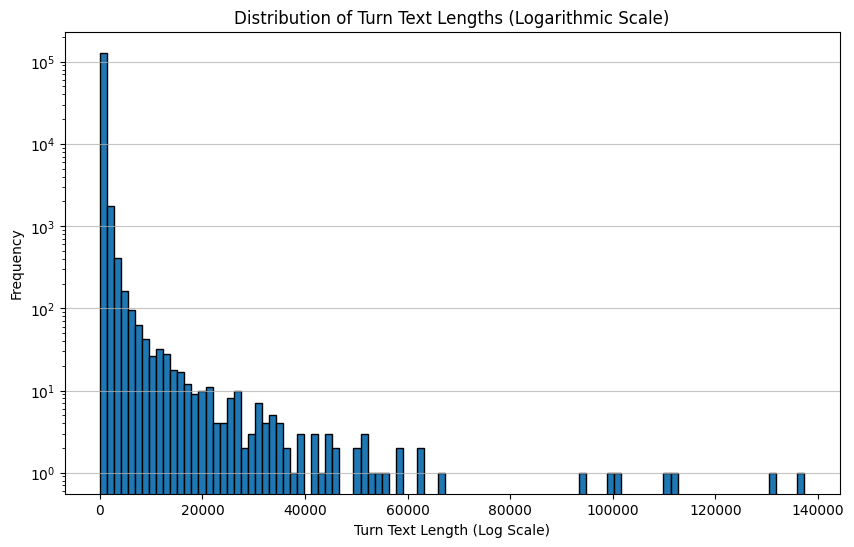

In [34]:
import matplotlib.pyplot as plt

# Plot a histogram of the turn text lengths
plt.figure(figsize=(10, 6))
plt.hist(speaker_df1['turnText'].str.len(), bins=100, edgecolor='black')
plt.title('Distribution of Turn Text Lengths (Logarithmic Scale)')
plt.xlabel('Turn Text Length (Log Scale)')
plt.ylabel('Frequency')
plt.yscale('log')
plt.grid(axis='y', alpha=0.75)
plt.show()

*Note: The y-axis is logarithmic*

An interesting observation here is that the **vast** majority of turnText lengths are very short. This might be indicating that episodes where  multiple speakers are involved, they are often interrupting eachother thus leading to very short sentences/words. This is defintely something to consider  when we input the emotion-model with these short turntexts as this obscure the final distribution of  emotion classification for said episode. So we need to be careful here and consider  solutions...

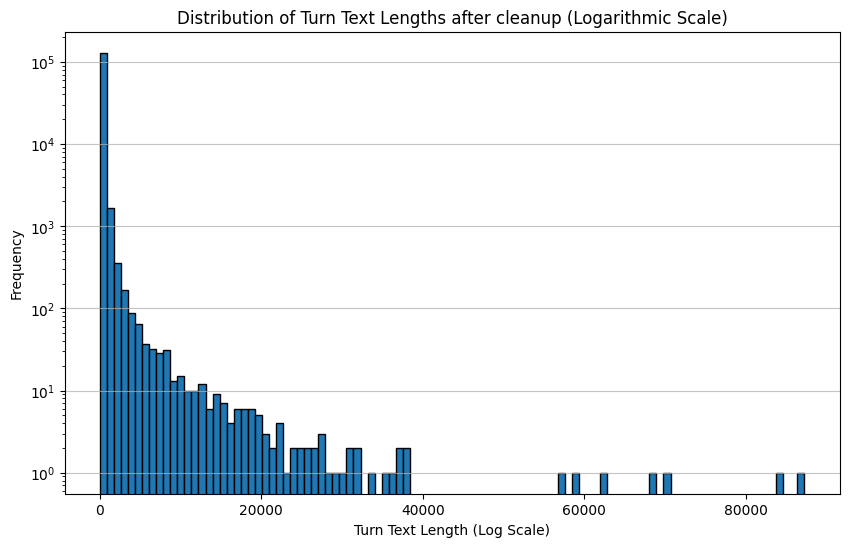

In [35]:
import matplotlib.pyplot as plt

# Plot a histogram of the turn text lengths
plt.figure(figsize=(10, 6))
plt.hist(speaker_df1['filtered_text'].str.len(), bins=100, edgecolor='black')
plt.title('Distribution of Turn Text Lengths after cleanup (Logarithmic Scale)')
plt.xlabel('Turn Text Length (Log Scale)')
plt.ylabel('Frequency')
plt.yscale('log')
plt.grid(axis='y', alpha=0.75)
plt.show()

#### 4.1.2 Distribution of Turns per Episode Visualized
This histogram shows the distribution of the number of speaker turns within each podcast episode. This helps us understand the typical conversational structure and density of the episodes in the dataset. 

An interesting observation here is that most episodes only include a few  amount of turns. This  indicates that many podcasts only has single speakers, thus resulting in one long continuing  turn for the given episode.

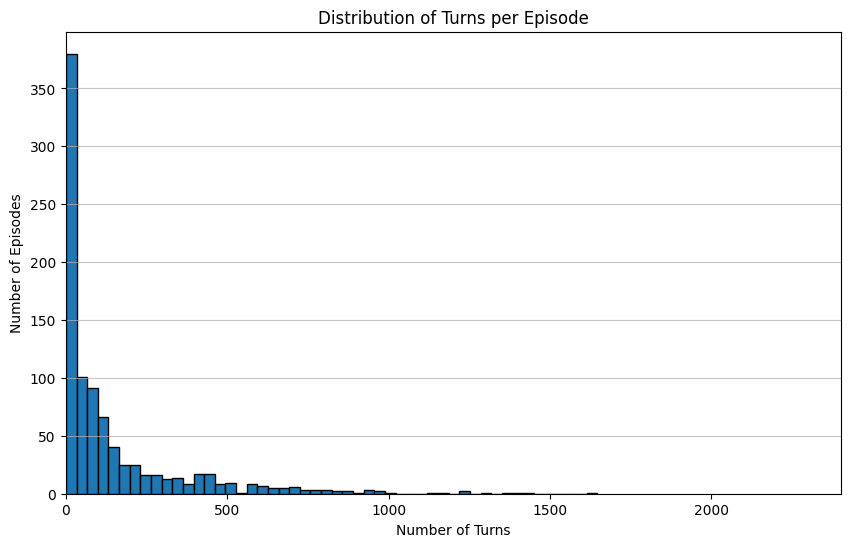

In [36]:
import matplotlib.pyplot as plt

# Calculate the number of turns per episode
turns_per_episode_counts = speaker_df1.groupby('mp3url').size()

# Plot a histogram of the number of turns per episode
plt.figure(figsize=(10, 6))
plt.hist(turns_per_episode_counts, bins=50, edgecolor='black')
plt.title('Distribution of Turns per Episode')
plt.xlabel('Number of Turns')
plt.ylabel('Number of Episodes')
plt.xlim(0, 2400)
plt.grid(axis='y', alpha=0.75)
plt.show()

## 4.2 Episode-Level Dataset Statistics

  To ensure that our episode-level analyses and classification tasks are well-grounded, we first need to understand the overall structure and composition of the episode metadata.
  Specifically, we want to examine how categories are distributed across episodes, how many unique topics are represented, and whether the data is complete and consistent enough to support downstream modeling.
  These statistics help us assess the feasibility of episode-level classification and inform key preprocessing decisions such as which category fields to include or discard.






> Before we  look at some statistics for the Episode-Level Dataset, there are  a few things we need to explain. First, each episode contains a "list" of categories expanding from category1 to category10. The main category for a given episode is found in category1  and each subsequent category is other related or secondary categories  for example: epTitle: "Sing Out Speak Out", category1: "music", category2: "comedy" ect. Antoher thing to note is that not all categories is expected  to be  represented for any given episode, for example continouing from "Sing Out Speak Out", category3: None, category4: None, ect.

With that being said, here are the things we wish to answer in following code cell:

- How many unique episodes?

- Total number of unique categories?

- How many episodes contain multiple categories?

- What categories are represented (for each category_x)?

- Are there any missing values in key columns?

In [37]:
# How many unique episodes?
unique_episodes_count = len(episode_df1['mp3url'].unique())
print(f"Number of unique episodes: {unique_episodes_count}")

# How many different categories in total?
category_columns = [f'category{i}' for i in range(1, 9)]
all_categories = episode_df1[category_columns].values.flatten()
unique_categories = pd.Series(all_categories).dropna().unique()
total_unique_categories = len(unique_categories)
print(f"\nTotal number of unique categories: {total_unique_categories}")

# Number of episodes with each category
print("\nNumber of episodes with each category:")
for col in category_columns:
    count = episode_df1[col].notnull().sum()
    print(f"{col}: {count}/{unique_episodes_count}")


# What categories are represented and any imbalance?
# We can look at the distribution of the first category as a starting point
print("\nDistribution of Category1:")
print('Number of unique categories: ', len(episode_df1['category1'].value_counts()))
print(episode_df1['category1'].value_counts())

print("\nDistribution of Category2:")
print('Number of unique categories: ', len(episode_df1['category2'].value_counts()))
print(episode_df1['category2'].value_counts())

print("\nDistribution of Category3:")
print('Number of unique categories: ', len(episode_df1['category3'].value_counts()))
print(episode_df1['category3'].value_counts())


# Check for missing values in key columns
print("\nMissing values in episode_df1:")
print(episode_df1[['epTitle', 'mp3url', 'podTitle', 'category1']].isnull().sum())


Number of unique episodes: 9984

Total number of unique categories: 99

Number of episodes with each category:
category1: 9984/9984
category2: 8075/9984
category3: 4257/9984
category4: 2055/9984
category5: 1152/9984
category6: 565/9984
category7: 273/9984
category8: 13/9984

Distribution of Category1:
Number of unique categories:  20
category1
religion      1982
business      1153
society       1118
education      977
sports         901
health         779
news           496
comedy         490
arts           411
music          372
tv             364
leisure        331
kids           135
science        131
technology     115
fiction         58
true crime      48
history         42
government      41
games           40
Name: count, dtype: int64

Distribution of Category2:
Number of unique categories:  75
category2
spirituality        1982
culture             1118
fitness              762
self improvement     536
film                 364
entrepreneurship     341
politics             193
ma

The first thing we find interesting here is that category1 only contains 20 unique categories, while category2 and category3 contain 75 and 74 categories respectively.
We might have expected the main category (category1) to include the broadest variety, since it represents the primary classification of each episode.
However, the opposite pattern suggests that the dataset’s taxonomy is hierarchical: the primary category field (category1) represents a smaller, curated set of high-level genres (e.g., Business, Religion, Sports), while the secondary and tertiary category fields (category2, category3) include more granular or cross-cutting themes (e.g., Football, How to, or Medicine).
This indicates that episodes are first assigned to a broad genre, and then optionally tagged with additional, more specific topics.

Another notable pattern is that the vast majority of episodes are assigned exactly two categories, after which the count of episodes decreases roughly by half with each additional category (from around 8,000 with two categories, to 4,000 with three, and so on).   

Based on these observations, we still need to determine the appropriate level of category granularity for our classification task.
One option is to train the model to predict only the primary category (category1), treating it as a single-label classification problem.
Alternatively, we could extend this to a multi-label setting by including the top 3–5 categories per episode, capturing the broader thematic range that often characterizes podcast content.  
Another evaluation strategy could involve comparing the model’s top-N predicted categories (e.g., top 10) against the ground truth to assess semantic overlap and generalization.
This decision will depend on the trade-off between model complexity, interpretability, and available training data, which we plan to explore further in the next milestone.

### 4.2.1 Distribution of Top 20 Most Frequent Categories (all categories)

Here we show the top 20 most frequent categories which are taken from all categories from 1 to 8. This helps us understand the overall thematic landscape of different topics across the dataset, providing insights into the dominant themes and potential areas for more granular analysis.

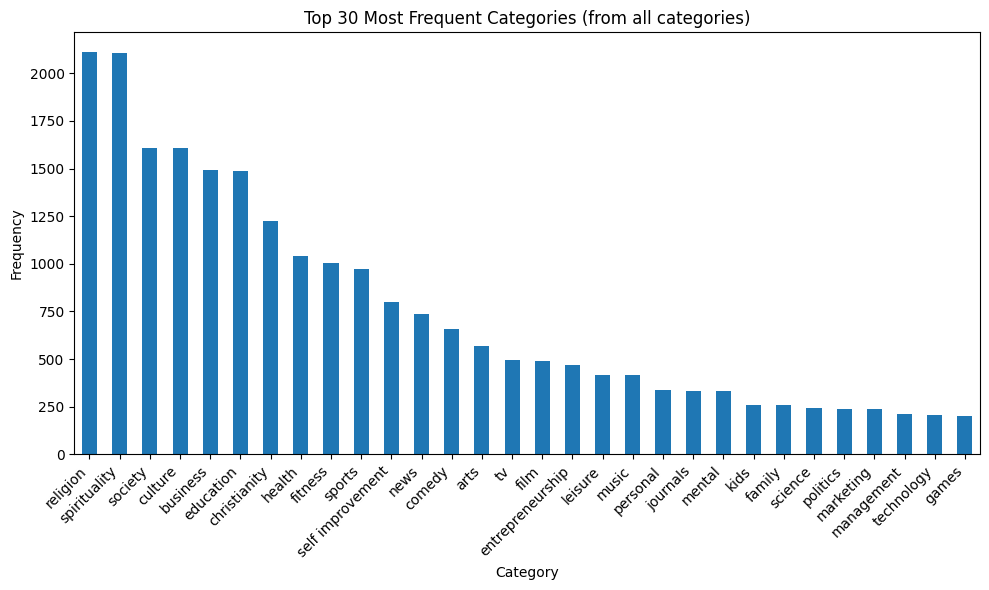

In [38]:
import matplotlib.pyplot as plt
import pandas as pd

# Combine all category columns into a single Series
category_columns = [f'category{i}' for i in range(1, 9)]
all_categories = episode_df1[category_columns].values.flatten()
all_categories_series = pd.Series(all_categories).dropna()

# Get the top 30 most frequent categories
top_30_categories = all_categories_series.value_counts().head(30)

# Create a bar chart of the top 30 categories
plt.figure(figsize=(10, 6))
top_30_categories.plot(kind='bar')
plt.title('Top 30 Most Frequent Categories (from all categories)')
plt.xlabel('Category')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 4.2.2 Distribution of Top 20 Most Frequent Categories (from category1)

Here we show the top 20 most frequent categories in category1. This provides insights into the primary genres and main topics covered by the podcasts in the dataset. Analyzing the distribution of the primary category is crucial for understanding the core thematic composition of the data and for informing decisions about episode-level classification tasks.

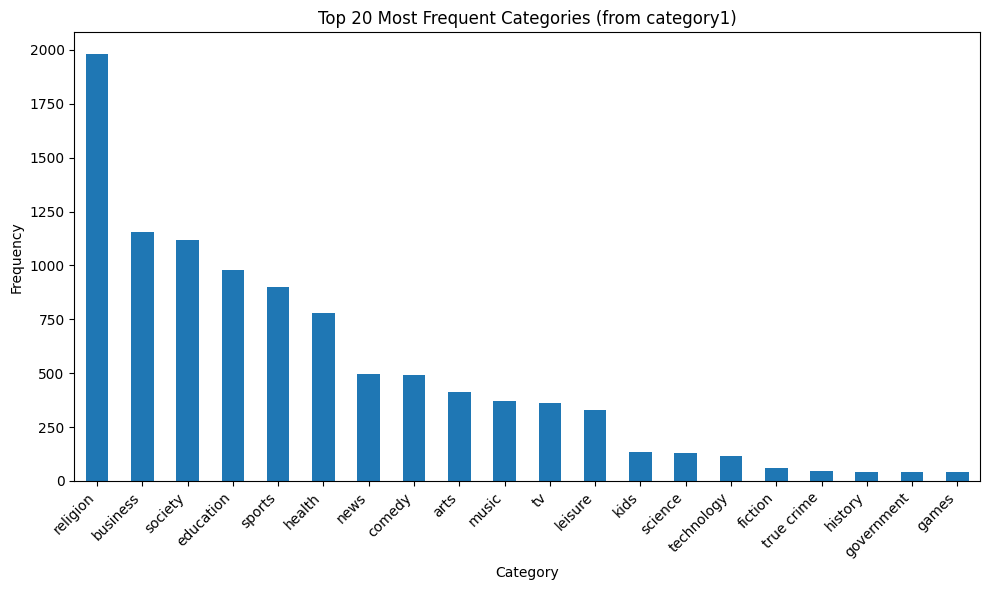

In [39]:
import matplotlib.pyplot as plt
import pandas as pd

# Combine all category columns into a single Series
all_categories = episode_df1['category1'].values.flatten()
all_categories_series = pd.Series(all_categories).dropna()

# Get the top 20 most frequent categories
top_20_categories = all_categories_series.value_counts().head(20)

# Create a bar chart of the top 20 categories
plt.figure(figsize=(10, 6))
top_20_categories.plot(kind='bar')
plt.title('Top 20 Most Frequent Categories (from category1)')
plt.xlabel('Category')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 4.2.3 Distribution of Top 30 Most Frequent Categories (from category2)

And here we show the top 30 most frequent categories in category2. Examining this distribution helps reveal common secondary themes or sub-genres present in the podcast episodes.

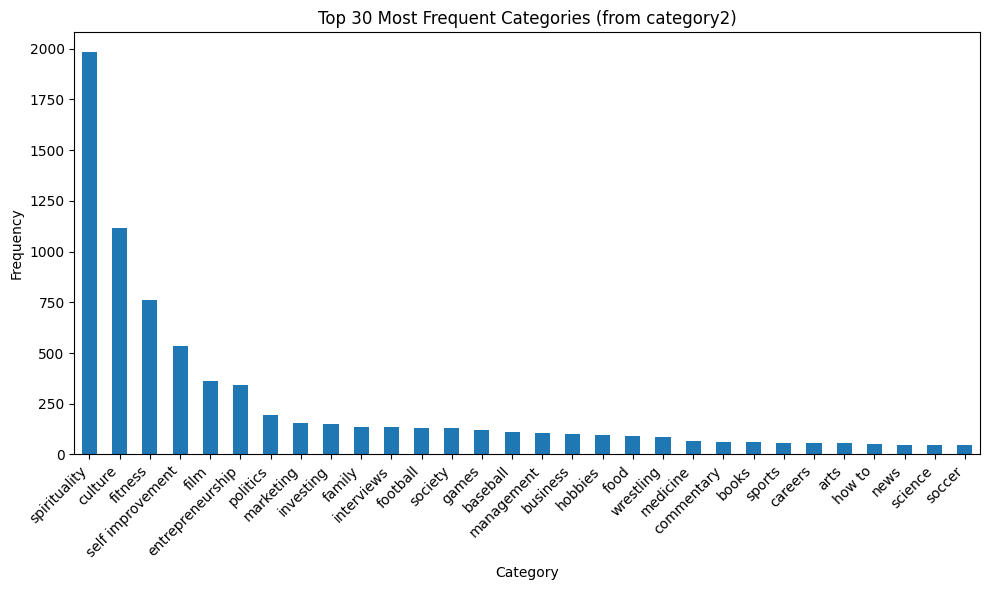

In [40]:
import matplotlib.pyplot as plt
import pandas as pd

# Combine all category columns into a single Series
all_categories = episode_df1['category2'].values.flatten()
all_categories_series = pd.Series(all_categories).dropna()

# Get the top 30 most frequent categories
top_30_categories = all_categories_series.value_counts().head(30)

# Create a bar chart of the top 30 categories
plt.figure(figsize=(10, 6))
top_30_categories.plot(kind='bar')
plt.title('Top 30 Most Frequent Categories (from category2)')
plt.xlabel('Category')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Next Steps (Proof of Concept) 

### 5.1 Emotional Detector  (Early Demonstration)

In [41]:
from transformers import pipeline

# Assume df_speaker contains columns: ['mp3url', 'speaker', 'turnText']
df_sample = speaker_df1.dropna(subset=['turnText']).sample(30, random_state=41)  # tiny sample

# Load emotion detection model
emotion_classifier = pipeline("text-classification", model="j-hartmann/emotion-english-distilroberta-base", top_k=None)

# Apply model to each turn
results = []
for i, text in enumerate(df_sample['turnText']):
    preds = emotion_classifier(text[:512])  # truncate long texts
    results.append(preds[0])  # get top prediction

# Add results to dataframe
df_sample['emotion'] = [r[0]['label'] for r in results]
df_sample['emotion_score'] = [r[0]['score'] for r in results]
df_sample.head()

c:\Users\Gusta\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,speaker,turnText,startTime,endTime,mp3url,inferredSpeakerRole,turnCount,filtered_text,epTitle,num_speakers,emotion,emotion_score
72226,[SPEAKER_01],done in success with it,2897.07,2898.76,https://traffic.omny.fm/d/clips/820f09cf-2ace-4180-a92d-aa4c0008f5fb/c1c22a03-f4e2-49e4-9eff-abb2003ac099/b0308320-47a4-4d92-ac96-abc300544d8e/audio.mp3?utm_source=Podcast&in_playlist=25111702-47b4-423f-9d57-abb2003ac0a7&t=1590127264,NO_INFERRED_ROLE,209,done success,"The end of the office Plus, why was Australia trying to pick a fight with China",1,neutral,0.408146
447,[SPEAKER_02],i think it is up there i think its a pretty high goal because like i said microphones are expensive like the setup that im using right now its about 900 bucks right so thats why all of my podcasts come through with this so,5559.12,5578.46,https://traffic.libsyn.com/secure/glassboxpodcast/Ep_46_Reg.mp3?dest-id=362054,host,646,think think pretty high goal like said microphones expensive like setup im using right 900 bucks right thats podcasts come,Ep 46 - Broken Missionary plus Case for Book of Mormon pt. 4,1,surprise,0.556119
111560,"[SPEAKER_08, SPEAKER_11]",consistent basis points,7755.96,7757.40,https://podcasts.captivate.fm/media/28dbe335-70b9-4522-b082-f49501280635/e07-drake-dark-lane-demo-tapes.mp3,NO_INFERRED_ROLE,1652,consistent basis points,"1st Listen, New Album Reviews E07 - Drake, Dark Lane Demo Tapes",2,neutral,0.910187
98499,[SPEAKER_02],this shirt made down a court thatd be a very funny shirt i was actually talking to my sister yesterday though uh or whatever all these days are the same about coy does not about coy does god no q is,3266.92,3277.82,https://feeds.soundcloud.com/stream/824334322-trashdelivery-38-is-this-obamagate.mp3,NO_INFERRED_ROLE,588,shirt made court thatd funny shirt actually talking sister yesterday though uh whatever days coy coy god q,#38 - Is This Obamagate?,1,surprise,0.786173
7551,[SPEAKER_08],to bear always on the side of china and we fund it so i want to look into it yes please,1732.18,1740.00,https://dl.iono.fm/epi/prov_1500/epi_866347_medium.m4a?p=rss,NO_INFERRED_ROLE,80,bear always side china fund want look yes please,Inside Covid-19: R249pm medical aid for 1.2m household workers; Black tobacco farmers say Govt supporting crooks. Ep 39,1,neutral,0.651635


#### 5.1.1 Aggregate emotions per episode

By aggregating emotion predictions across all speaker turns within each episode, we can understand the overall emotional landscape of a conversation. For each episode, we calculate the proportion of turns associated with different emotions, providing insight into the emotional dynamics throughout the discussion. This aggregation helps reveal patterns like emotional progression, dominant moods, or significant emotional shifts during the episode.

Note: As this small demo only showcases 30 random turnTexts for 30 random episodes, the distribution will only show one emotion for each episode, but this is just to give some insights to what we aim for.

In [42]:
# Group by episode (mp3url) - group by episode name instead somehow
emotion_counts = (
    df_sample.groupby(['epTitle', 'emotion'])
    .size()
    .unstack(fill_value=0)
)

emotion_ratios = emotion_counts.div(emotion_counts.sum(axis=1), axis=0)
emotion_ratios.head(10)


emotion,anger,joy,neutral,sadness,surprise
epTitle,,,,,
#26 - Taco Bell & Etymology,0.0,0.0,0.0,0.0,1.0
#38 - Is This Obamagate?,0.0,0.0,0.0,0.0,1.0
09: Our First,0.0,0.0,1.0,0.0,0.0
"184: Faith and Optimism - John Green II chats with us about believing in students so they can believe in themselves, the power of never giving up, and the importance of learning to not take things per",0.0,0.0,0.0,1.0,0.0
"1st Listen, New Album Reviews E07 - Drake, Dark Lane Demo Tapes",0.0,0.0,1.0,0.0,0.0
A Budding Affair,0.0,0.0,1.0,0.0,0.0
Console Shock Ep65 Bob from Retro RGB,0.0,0.0,1.0,0.0,0.0
Cybercrimes and Fraud - Interview with LVMPD Detective Jeff Lomas,0.0,0.0,1.0,0.0,0.0
Dane Cook Returns,0.0,1.0,0.0,0.0,0.0


### 5.1.2 Quick visualization

The emotion distribution below shows that 'neutral' is indeed the most frequent classification, which aligns with the nature of podcast conversations - many turns consist of short, functional utterances even after filtering, that carry little emotional content. While the model can detect a range of emotions (anger, disgust, fear, joy, neutral, sadness, surprise), neutral dominates the distribution due to these brief conversational elements. This suggests that for meaningful emotional analysis, we might want to focus on longer turns or aggregate emotions across conversation segments rather than individual short turns.

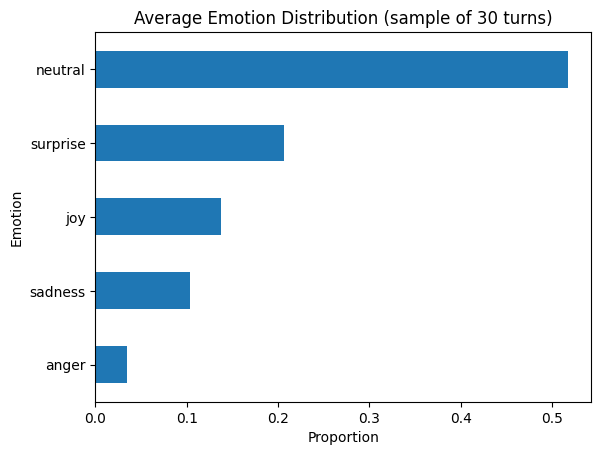

In [43]:
import matplotlib.pyplot as plt

emotion_ratios.mean().sort_values().plot(kind='barh')
plt.title("Average Emotion Distribution (sample of 30 turns)")
plt.xlabel("Proportion")
plt.ylabel("Emotion")
plt.show()


#### 5.1.3 Emotional Graph (TO DO)

In [44]:
# TO DO

### 5.2 Category Classification

This section contains only the initial data-preparation steps for a future episode-level category classification task. It does NOT include model training or evaluation. The purpose here is to produce a clean, ready dataset for later modeling.

Contents:
- Sample selection & label extraction: filter episodes with non-null `combined_turnText` and `category1`; optionally restrict to the top‑N frequent categories to keep the sample manageable; extract and encode the primary category as the target vector.
- Text vectorization (TF‑IDF): fit a `TfidfVectorizer` (unigrams + bigrams, basic stopword filtering, and an optional max feature/min document frequency) and transform the selected episode texts into sparse TF‑IDF features.

Result: a prepared feature matrix (`X_tfidf`) and label vector (`y`) stored for the next assignment where we will implement model training, evaluation, and error analysis.

#### 5.2.1 Sample Selection and Label Extraction

Here we'll:
1. Load episode data and select relevant columns
2. Keep only episodes with non-null text and category
3. Focus on top-K most frequent categories
4. Create feature matrix X and target vector y

In [45]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

# Load episode data (assuming we have episode_df1 from previous notebook)
# Select rows with non-null text and category
df = episode_df1[['epTitle', 'combined_turnText', 'category1']].dropna()

# Keep only top 20 most frequent categories
top_k = 20
top_categories = df['category1'].value_counts().nlargest(top_k).index
df = df[df['category1'].isin(top_categories)]

# Create feature matrix X and target vector y
X = df['combined_turnText']
y = df['category1']

# Encode labels
le = LabelEncoder()
y = le.fit_transform(y)

print("Dataset shape:", df.shape)
print("\nCategory distribution:")
for i, category in enumerate(le.classes_):
    count = (y == i).sum()
    print(f"{category}: {count} episodes ({count/len(y):.1%})")

Dataset shape: (907, 3)

Category distribution:
arts: 41 episodes (4.5%)
business: 157 episodes (17.3%)
comedy: 46 episodes (5.1%)
education: 130 episodes (14.3%)
fiction: 3 episodes (0.3%)
government: 3 episodes (0.3%)
health: 97 episodes (10.7%)
history: 1 episodes (0.1%)
kids: 4 episodes (0.4%)
leisure: 41 episodes (4.5%)
music: 47 episodes (5.2%)
news: 23 episodes (2.5%)
religion: 114 episodes (12.6%)
science: 4 episodes (0.4%)
society: 96 episodes (10.6%)
sports: 57 episodes (6.3%)
technology: 8 episodes (0.9%)
true crime: 5 episodes (0.6%)
tv: 30 episodes (3.3%)


#### 5.2.2 Text Vectorization (TF-IDF)

Convert the text data into numerical features using TF-IDF (Term Frequency-Inverse Document Frequency). This:
- Captures word importance through term frequency and document frequency
- Handles common words appropriately through IDF weighting
- Creates a sparse feature matrix suitable for classification

In [46]:
# Initialize TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=10000,  # Limit vocabulary size
    min_df=5,           # Ignore terms that appear in < 5 documents
    ngram_range=(1, 2), # Use unigrams and bigrams
    stop_words='english'
)

# Fit and transform the text data
X_tfidf = tfidf.fit_transform(X)

print("TF-IDF feature matrix shape:", X_tfidf.shape)
print("Number of features:", len(tfidf.get_feature_names_out()))
print("\nSample features:", list(tfidf.get_feature_names_out())[:10])

TF-IDF feature matrix shape: (907, 10000)
Number of features: 10000

Sample features: ['10', '10 15', '10 days', '10 million', '10 minute', '10 minutes', '10 year', '10 years', '100', '100 years']


#### 5.2.3 Planned model training, evaluation and next steps (summary)



In a later assignment we will build on the prepared features (`X_tfidf`) and labels (`y`) to train and evaluate classification models. High-level plan:

- Train/validation split: stratified 80/20 (optionally hold out a small test set); consider cross-validation for robust estimates.
- Baseline model: Logistic Regression (class_weight='balanced', solver='saga' or 'liblinear') with optional hyperparameter tuning via grid search or randomized CV.
- Metrics: report accuracy, precision/recall/F1 (micro/macro), and per-class support; plot a confusion matrix and calibration curves where relevant.
- Interpretability & error analysis: inspect top features (model coefficients) per class, review misclassified episode excerpts to diagnose label noise or ambiguous content.
- Probabilities & thresholding: show top‑k predicted categories and confidences; consider thresholding for precision-oriented applications.
- Persistence: save vectorizer/tokenizer, label encoder, and trained model (joblib) for later inference.

Future upgrades: experiment with pretrained embeddings or fine-tuned transformers, multi-label setups, and class-rebalancing strategies.

### 5.3 Potential Brand Safety Analysis



This section might explore brand safety analysis of podcast content, though the specific approach and implementation details are still under consideration. Here's a preliminary outline of what could potentially be included:

1. **Content Safety Assessment** (tentative approach)
   - We might analyze text for potentially sensitive or controversial content
   - This could involve identifying mentions of specific topics or themes
   - The scope would need careful definition based on available resources and project requirements

2. **Possible Analysis Methods**
   - We could consider keyword-based detection of sensitive topics
   - Alternatively, we might explore pre-trained content classification models
   - The choice of method would depend on feasibility and accuracy requirements

3. **Potential Challenges**
   - Context interpretation in conversational content
   - Handling nuanced discussions of sensitive topics
   - Balancing detection accuracy with false positives
   - Need for careful consideration of bias in analysis methods

4. **Possible Output Format**
   - If implemented, we might provide episode-level safety ratings
   - Could potentially include segment-level annotations
   - Format and granularity would need to align with practical use cases

Note: This section represents potential future work and the actual implementation may vary significantly based on feasibility analysis and project constraints. The approach to brand safety analysis would need careful consideration of ethical implications and bias mitigation.

### 5.4 Audience Alignment Prediction (TO DO)

This short exploratory section considers ways to estimate which audience segments are likely to engage with an episode using its content signals (topics, tone, and emotion). Based on emotional and topical embeddings, we could apply a zero-shot classification approach to infer likely audience segments (e.g., “young professionals”, “tech enthusiasts”, “general entertainment”). This is an exploratory feasibility step intended to demonstrate the potential of emotion-aware audience profiling rather than a committed methodology; the final approach will depend on available listener data and time constraints.

# Personal questions  and Todo


*   README.md including abstract, contribrutions(?), methods and proposed timeline - Oguzhan
*   Appendix - Repo organisation (pdf-file) - Oguzhan

*   Refine and further explain PoC section (display episode title instead of mp3url!) - Gustav (done)

*   Include PoC demonstration for category classification? (Just notes) - Gustav (done)

* Add stop words to preprocessing - Cristina

* Think about the emotional graph of an episode - Cristina

- **IMPORTANTE**! Look at the 'Examples' section... for some reason some episodes dont have any turnText. i dont know if im doing something wrong  or if we made some mistakes in the preprocessing step...

- Also, not TO DO, but i descriped our next steps/future works


how many emotions pr turntext